In [2]:
import torch
print("PyTorch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())
print("CUDA version :", torch.version.cuda)
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "not available")

PyTorch : 2.14.0+cu126
CUDA : True
CUDA version : 12.6
GPU : NVIDIA GeForce RTX 3050 Laptop GPU


# 1. SETUP

In [3]:
import copy
import gc
import os
import random
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def seed_everything(seed) :
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
seed_everything(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. CONFIG

In [4]:
SEEDS = [42, 43, 44] # default 42
DATA_DIR = Path("data/processed")
CHECKPOINT_DIR = Path("checkpoints")
REPORT_DIR = Path("reports")
FIG_DIR = REPORT_DIR / "figures"
METRICS_DIR = REPORT_DIR / "metrics"
for directory in (CHECKPOINT_DIR, FIG_DIR, METRICS_DIR) :
    directory.mkdir(parents=True, exist_ok=True)
assert DATA_DIR.is_dir(), f"Dataset terproses tidak ditemukan: {DATA_DIR}"

IMG_SIZE = (224, 224)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
HIDDEN_DIM = 512
NUM_CLASSES = 4
STAGE_MAX_EPOCHS = 50
PATIENCE = 5
FINE_TUNE_LR_DIV = 10
BASE_CONFIG = {"optimizer": "Adam", "lr": 1e-4, "dropout": 0.5, "batch_size": 16}
GRID = {
    "optimizer": ["Adam", "AdamW"],
    "lr": [1e-3, 1e-4, 1e-5],
    "dropout": [0.2, 0.3, 0.4, 0.5],
    "batch_size": [16, 32],
}
CLASS_DISPLAY_NAMES = {
    "leaf_curl": "Leaf Curl",
    "leaf_spot": "Leaf Spot",
    "yellowish": "Yellowish",
    "healthy_leaf": "Healthy Leaf",
}
assert len(GRID["optimizer"]) * len(GRID["lr"]) * len(GRID["dropout"]) * len(GRID["batch_size"]) == 48
assert BASE_CONFIG["optimizer"] in GRID["optimizer"]
assert BASE_CONFIG["lr"] in GRID["lr"]
assert BASE_CONFIG["dropout"] in GRID["dropout"]
assert BASE_CONFIG["batch_size"] in GRID["batch_size"]

# 3. LOAD DATASET

In [5]:
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, scale=(0.9, 1.1), fill=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
validation_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
datasets_by_split = {"train": train_dataset, "validation": validation_dataset, "test": test_dataset}
class_names = train_dataset.classes
assert len(class_names) == NUM_CLASSES
assert train_dataset.class_to_idx == validation_dataset.class_to_idx == test_dataset.class_to_idx

def _class_counts(dataset) :
    counts = np.bincount(dataset.targets, minlength=len(dataset.classes))
    return dict(zip(dataset.classes, counts.tolist()))

split_rows = []
for split_name, dataset in datasets_by_split.items() :
    split_rows.append({"Split": split_name, "Total": len(dataset), **_class_counts(dataset)})
display(pd.DataFrame(split_rows).set_index("Split"))

def make_loaders(batch_size, seed) :
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator, num_workers=0, pin_memory=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, validation_loader

def make_test_loader(batch_size) :
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

,Total,healthy_leaf,leaf_curl,leaf_spot,yellowish
Split,,,,,
train,1099,282,264,281,272
validation,235,60,56,60,59
test,236,61,56,60,59


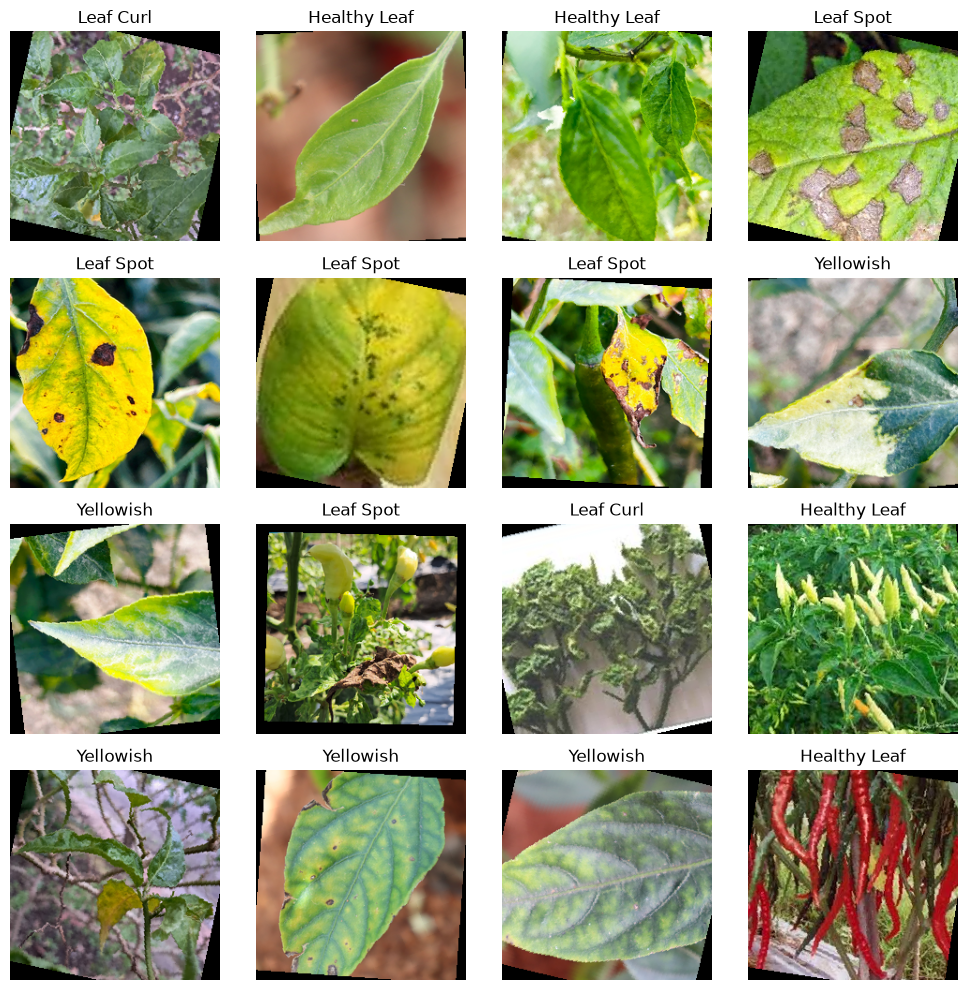

In [6]:
# Visualisasi 4x4 sampel train yang sudah diaugmentasi.
def denormalize(image_tensor) :
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)

sample_indices = np.random.default_rng(seed).choice(len(train_dataset), size=min(16, len(train_dataset)), replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for axis, sample_index in zip(axes.flat, sample_indices) :
    image, target = train_dataset[sample_index]
    axis.imshow(denormalize(image).permute(1, 2, 0))
    axis.set_title(CLASS_DISPLAY_NAMES.get(class_names[target], class_names[target]))
    axis.axis("off")
for axis in axes.flat[len(sample_indices):] :
    axis.axis("off")
plt.tight_layout()
plt.show()

# 4. CALLBACK

In [7]:
class EarlyStopping :
    def __init__(self, patience=PATIENCE) :
        self.patience = patience
        self.best_loss = float("inf")
        self.best_state_dict = None
        self.wait = 0

    def __call__(self, val_loss, model) :
        if val_loss < self.best_loss :
            self.best_loss = val_loss
            self.best_state_dict = copy.deepcopy(model.state_dict())
            self.wait = 0
            return False
        self.wait += 1
        return self.wait >= self.patience

    def restore(self, model) :
        if self.best_state_dict is None :
            raise RuntimeError("Belum ada state terbaik untuk dipulihkan.")
        model.load_state_dict(self.best_state_dict)

def save_checkpoint(model, path, **metadata) :
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"model_state_dict": model.state_dict(), **metadata}, path)
    return path

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

# 5. FUNCTION EVALUASI

In [8]:
def evaluate_loss_accuracy(model, loader) :
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_items = 0
    with torch.no_grad() :
        for images, targets in loader :
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            total_loss += criterion(logits, targets).item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_items += targets.size(0)
    if total_items == 0 :
        raise ValueError("Loader evaluasi kosong.")
    return total_loss / total_items, total_correct / total_items

def predict_all(model, loader) :
    model.eval()
    y_true, y_pred, probs = [], [], []
    with torch.no_grad() :
        for images, targets in loader :
            logits = model(images.to(device))
            batch_probs = torch.softmax(logits, dim=1)
            y_true.extend(targets.numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
            probs.append(batch_probs.cpu().numpy())
    return np.asarray(y_true), np.asarray(y_pred), np.concatenate(probs, axis=0) if probs else np.empty((0, NUM_CLASSES))

def compute_metrics(y_true, y_pred, probs, loss) :
    del probs
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "loss": float(loss),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "classification_report": classification_report(y_true, y_pred, output_dict=True, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES)),
    }

def count_parameters(model) :
    return sum(parameter.numel() for parameter in model.parameters())

def model_size_mb(model) :
    temporary_path = None
    try :
        with tempfile.NamedTemporaryFile(suffix=".pth", delete=False) as temporary_file :
            temporary_path = temporary_file.name
        torch.save(model.state_dict(), temporary_path)
        return Path(temporary_path).stat().st_size / (1024 ** 2)
    finally :
        if temporary_path and Path(temporary_path).exists() :
            Path(temporary_path).unlink()

def measure_latency(model, warmup=20, runs=100) :
    model.eval()
    sample = torch.zeros(1, 3, IMG_SIZE[0], IMG_SIZE[1], device=device)
    timings = []
    with torch.no_grad() :
        for _ in range(warmup) :
            model(sample)
        if device.type == "cuda" :
            torch.cuda.synchronize()
        for _ in range(runs) :
            start = time.perf_counter()
            model(sample)
            if device.type == "cuda" :
                torch.cuda.synchronize()
            timings.append((time.perf_counter() - start) * 1000)
    return float(np.mean(timings)), float(np.std(timings))

# 6. MODEL

In [9]:
from torchvision import models

In [10]:
def make_head(input_features, dropout) :
    return nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(input_features, HIDDEN_DIM),
        nn.ReLU(),
        nn.Dropout(p=dropout),
        nn.Linear(HIDDEN_DIM, NUM_CLASSES),
    )

class FeatureBackbone(nn.Module) :
    def __init__(self, features) :
        super().__init__()
        self.features = features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()

    def forward(self, images) :
        return self.flatten(self.pool(self.features(images)))

class SingleBackboneModel(nn.Module) :
    def __init__(self, features, backbone_name, dropout) :
        super().__init__()
        self.features = features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = make_head(1280, dropout)
        self.backbone_name = backbone_name

    def forward(self, images) :
        features = self.pool(self.features(images)).flatten(1)
        return self.head(features)

class FusionModel(nn.Module) :
    def __init__(self, mobilenet_features, efficientnet_features, dropout) :
        super().__init__()
        self.mobilenet = FeatureBackbone(mobilenet_features)
        self.efficientnet = FeatureBackbone(efficientnet_features)
        self.head = make_head(2560, dropout)

    def forward(self, images) :
        mobilenet_features = self.mobilenet(images)
        efficientnet_features = self.efficientnet(images)
        fused_features = torch.cat((mobilenet_features, efficientnet_features), dim=1)
        return self.head(fused_features)


def build_mobilenet(dropout) :
    backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    assert len(backbone.features) == 19
    return SingleBackboneModel(backbone.features, "mobilenet", dropout).to(device)


def build_efficientnet(dropout) :
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    assert len(backbone.features) == 9
    return SingleBackboneModel(backbone.features, "efficientnet", dropout).to(device)


def build_hybrid(dropout) :
    mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    assert len(mobilenet.features) == 19
    assert len(efficientnet.features) == 9
    return FusionModel(mobilenet.features, efficientnet.features, dropout).to(device)


def _backbone_parts(model) :
    if isinstance(model, FusionModel) :
        return [("MobileNetV2", model.mobilenet), ("EfficientNetB0", model.efficientnet)]
    return [(model.backbone_name, model)]


def _last_conv_channels(module) :
    channels = [layer.out_channels for layer in module.modules() if isinstance(layer, nn.Conv2d)]
    if not channels :
        raise RuntimeError("Tidak menemukan Conv2d pada stage backbone.")
    return channels[-1]


def _stage_channel_table(model) :
    rows = []
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = 14 if "mobilenet" in backbone_name.lower() else 6
        for index in range(start_index, len(backbone.features)) :
            rows.append({
                "Backbone": backbone_name,
                "Feature index": index,
                "Output channels": _last_conv_channels(backbone.features[index]),
            })
    return pd.DataFrame(rows)


def print_unfrozen_stage_channels(model) :
    table = _stage_channel_table(model)
    display(table)
    return table


def freeze_backbone(model) :
    for parameter in model.parameters() :
        parameter.requires_grad = False
    for parameter in model.head.parameters() :
        parameter.requires_grad = True
    return model


def unfreeze_last_stages(model) :
    freeze_backbone(model)
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = 14 if "mobilenet" in backbone_name.lower() else 6
        for module in backbone.features[start_index:] :
            for parameter in module.parameters() :
                parameter.requires_grad = True
    print_unfrozen_stage_channels(model)
    return model


def set_train_mode(model, stage) :
    if stage not in (1, 2) :
        raise ValueError("stage harus 1 atau 2.")
    model.train()
    for _, backbone in _backbone_parts(model) :
        if stage == 1 :
            backbone.eval()
        else :
            for module in backbone.modules() :
                if module is backbone :
                    continue
                if any(parameter.requires_grad for parameter in module.parameters(recurse=False)) :
                    module.train()
                else :
                    module.eval()
    for module in model.modules() :
        if isinstance(module, nn.modules.batchnorm._BatchNorm) :
            module.eval()
    return model

mobilenet_model = build_mobilenet(BASE_CONFIG["dropout"])
efficientnet_model = build_efficientnet(BASE_CONFIG["dropout"])
hybrid_model = build_hybrid(BASE_CONFIG["dropout"])
print_unfrozen_stage_channels(hybrid_model)

,Backbone,Feature index,Output channels
0,MobileNetV2,14,160
1,MobileNetV2,15,160
2,MobileNetV2,16,160
3,MobileNetV2,17,320
4,MobileNetV2,18,1280
5,EfficientNetB0,6,192
6,EfficientNetB0,7,320
7,EfficientNetB0,8,1280


,Backbone,Feature index,Output channels
0,MobileNetV2,14,160
1,MobileNetV2,15,160
2,MobileNetV2,16,160
3,MobileNetV2,17,320
4,MobileNetV2,18,1280
5,EfficientNetB0,6,192
6,EfficientNetB0,7,320
7,EfficientNetB0,8,1280


In [11]:
def set_train_mode(model, stage) :
    if stage not in (1, 2) :
        raise ValueError("stage harus 1 atau 2.")
    model.train()
    for _, backbone in _backbone_parts(model) :
        if isinstance(model, FusionModel) :
            if stage == 1 :
                backbone.eval()
            else :
                backbone.train()
        elif stage == 1 :
            backbone.features.eval()
        else :
            backbone.features.train()
    for module in model.modules() :
        if isinstance(module, nn.modules.batchnorm._BatchNorm) :
            module.eval()
    return model

In [12]:
def _backbone_parts(model) :
    if isinstance(model, FusionModel) :
        return [("mobilenet", model.mobilenet), ("efficientnet", model.efficientnet)]
    return [(model.backbone_name, model)]


def _stage_start(backbone_name) :
    return 14 if backbone_name == "mobilenet" else 6


def print_unfrozen_stage_channels(model) :
    rows = []
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = _stage_start(backbone_name)
        for index in range(start_index, len(backbone.features)) :
            rows.append({
                "Backbone": backbone_name,
                "Feature index": index,
                "Output channels": _last_conv_channels(backbone.features[index]),
            })
    table = pd.DataFrame(rows)
    display(table)
    return table


def unfreeze_last_stages(model) :
    freeze_backbone(model)
    for backbone_name, backbone in _backbone_parts(model) :
        start_index = _stage_start(backbone_name)
        for module in backbone.features[start_index:] :
            for parameter in module.parameters() :
                parameter.requires_grad = True
    print_unfrozen_stage_channels(model)
    return model

print_unfrozen_stage_channels(hybrid_model)

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


# 7. TRAINING FUNCTION (2 Tahap)

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, stage, max_batches=None) :
    set_train_mode(model, stage)
    epoch_start = time.perf_counter()
    running_loss = 0.0
    running_correct = 0
    total_items = 0
    for batch_index, (images, targets) in enumerate(loader) :
        if max_batches is not None and batch_index >= max_batches :
            break
        images, targets = images.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda") :
            logits = model(images)
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * targets.size(0)
        running_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_items += targets.size(0)
    if total_items == 0 :
        raise ValueError("Loader training kosong atau max_batches terlalu kecil.")
    epoch_sec = time.perf_counter() - epoch_start
    return running_loss / total_items, running_correct / total_items, epoch_sec


def fit_stage(model, train_loader, val_loader, optimizer, max_epochs=STAGE_MAX_EPOCHS, patience=PATIENCE, stage=1) :
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=patience)
    history = []
    best_epoch = 0
    for epoch in range(1, max_epochs + 1) :
        train_loss, train_acc, epoch_sec = train_one_epoch(model, train_loader, criterion, optimizer, scaler, stage)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch_sec": epoch_sec,
        }
        history.append(row)
        print(
            f"stage={stage} epoch={epoch}/{max_epochs} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} sec={epoch_sec:.2f}"
        )
        if val_loss < early_stopping.best_loss :
            best_epoch = epoch
        # Early stopping memantau validation loss dan memulihkan bobot terbaik setelah loop.
        if early_stopping(val_loss, model) :
            print(f"Early stopping: stage {stage}, epoch {epoch}.")
            break
    early_stopping.restore(model)
    return history, best_epoch, len(history)


def build_optimizer(model, cfg, lr) :
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    if not parameters :
        raise ValueError("Tidak ada parameter trainable untuk optimizer.")
    if cfg["optimizer"] == "Adam" :
        return torch.optim.Adam(parameters, lr=lr, weight_decay=0.0)
    if cfg["optimizer"] == "AdamW" :
        return torch.optim.AdamW(parameters, lr=lr, weight_decay=0.01)
    raise ValueError(f"Optimizer tidak didukung: {cfg['optimizer']}")


def train_model(model, cfg, seed, name, max_epochs=None, stage1_max_epochs=None, stage2_max_epochs=None) :
    seed_everything(seed)
    stage1_epochs = stage1_max_epochs if stage1_max_epochs is not None else (max_epochs or STAGE_MAX_EPOCHS)
    stage2_epochs = stage2_max_epochs if stage2_max_epochs is not None else (max_epochs or STAGE_MAX_EPOCHS)
    train_loader, validation_loader = make_loaders(cfg["batch_size"], seed)
    total_start = time.perf_counter()

    freeze_backbone(model)
    stage1_optimizer = build_optimizer(model, cfg, cfg["lr"])
    stage1_start = time.perf_counter()
    history_stage1, best_epoch_stage1, epochs_stage1 = fit_stage(
        model, train_loader, validation_loader, stage1_optimizer,
        max_epochs=stage1_epochs, patience=PATIENCE, stage=1,
    )
    stage1_sec = time.perf_counter() - stage1_start

    unfreeze_last_stages(model)
    stage2_optimizer = build_optimizer(model, cfg, cfg["lr"] / FINE_TUNE_LR_DIV)
    stage2_start = time.perf_counter()
    history_stage2, best_epoch_stage2, epochs_stage2 = fit_stage(
        model, train_loader, validation_loader, stage2_optimizer,
        max_epochs=stage2_epochs, patience=PATIENCE, stage=2,
    )
    stage2_sec = time.perf_counter() - stage2_start

    checkpoint_path = CHECKPOINT_DIR / f"{name}_seed{seed}.pth"
    save_checkpoint(
        model,
        checkpoint_path,
        name=name,
        seed=seed,
        config=cfg,
        best_epoch_stage1=best_epoch_stage1,
        best_epoch_stage2=best_epoch_stage2,
        history={"stage1": history_stage1, "stage2": history_stage2},
    )
    all_epoch_seconds = [row["epoch_sec"] for row in history_stage1 + history_stage2]
    timing = {
        "total_sec": time.perf_counter() - total_start,
        "stage1_sec": stage1_sec,
        "stage2_sec": stage2_sec,
        "epoch_sec_mean": float(np.mean(all_epoch_seconds)),
        "epochs_run": epochs_stage1 + epochs_stage2,
    }
    return model, {"stage1": history_stage1, "stage2": history_stage2}, timing

In [14]:
import json
import re
import seaborn as sns

EVAL_REPORT_DIR = Path("reports")
EVAL_FIG_DIR = EVAL_REPORT_DIR / "figures"
EVAL_METRICS_DIR = EVAL_REPORT_DIR / "metrics"
EVAL_FIG_DIR.mkdir(parents=True, exist_ok=True)
EVAL_METRICS_DIR.mkdir(parents=True, exist_ok=True)
TEST_MANIFEST_PATH = Path("data/splits") / "test.csv"


def _json_safe(value) :
    if isinstance(value, np.ndarray) :
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)) :
        return value.item()
    if isinstance(value, dict) :
        return {str(key): _json_safe(item) for key, item in value.items()}
    if isinstance(value, list) :
        return [_json_safe(item) for item in value]
    return value


def _safe_name(value) :
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", value).strip("_")


def _source_metrics(y_true, y_pred, source_names) :
    result = {}
    for source in ("primer", "sekunder") :
        mask = np.asarray(source_names) == source
        if not np.any(mask) :
            result[source] = {"n": 0, "accuracy": None, "f1": None}
            continue
        result[source] = {
            "n": int(mask.sum()),
            "accuracy": float(accuracy_score(y_true[mask], y_pred[mask])),
            "f1": float(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)),
        }
    return result


def run_experiment(variant_name, builder, cfg, seed) :
    model = builder(cfg["dropout"])
    model, history, timing = train_model(model, cfg, seed, variant_name)
    # Test loader hanya boleh dipanggil di evaluasi final.
    test_loader = make_test_loader(cfg["batch_size"])
    test_loss, _ = evaluate_loss_accuracy(model, test_loader)
    y_true, y_pred, probs = predict_all(model, test_loader)
    test_metrics = compute_metrics(y_true, y_pred, probs, test_loss)
    params_total = count_parameters(model)
    size_mb = model_size_mb(model)
    latency_mean, latency_std = measure_latency(model)

    test_manifest = pd.read_csv(TEST_MANIFEST_PATH)
    image_ids = [Path(path).stem for path, _ in test_dataset.samples]
    source_lookup = test_manifest.set_index("image_id")["source"].to_dict()
    source_names = np.asarray([source_lookup[image_id] for image_id in image_ids])
    source_metrics = _source_metrics(y_true, y_pred, source_names)
    best_epoch_stage1 = min(history["stage1"], key=lambda row: row["val_loss"])["epoch"]
    best_epoch_stage2 = min(history["stage2"], key=lambda row: row["val_loss"])["epoch"]
    run_row = {
        "variant": variant_name,
        "seed": seed,
        "optimizer": cfg["optimizer"],
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
        "batch_size": cfg["batch_size"],
        "best_epoch_stage1": best_epoch_stage1,
        "best_epoch_stage2": best_epoch_stage2,
        "epochs_run": timing["epochs_run"],
        "train_time_sec": timing["total_sec"],
        "test_acc": test_metrics["accuracy"],
        "test_loss": test_metrics["loss"],
        "macro_precision": test_metrics["precision"],
        "macro_recall": test_metrics["recall"],
        "macro_f1": test_metrics["f1"],
        "params_total": params_total,
        "size_mb": size_mb,
        "latency_ms_mean": latency_mean,
        "latency_ms_std": latency_std,
        "n_primer": source_metrics["primer"]["n"],
        "n_sekunder": source_metrics["sekunder"]["n"],
        "acc_primer": source_metrics["primer"]["accuracy"],
        "acc_sekunder": source_metrics["sekunder"]["accuracy"],
        "f1_primer": source_metrics["primer"]["f1"],
        "f1_sekunder": source_metrics["sekunder"]["f1"],
    }
    runs_path = EVAL_METRICS_DIR / "runs.csv"
    runs_frame = pd.DataFrame([run_row])
    if runs_path.exists() :
        existing_runs = pd.read_csv(runs_path)
        existing_runs = existing_runs[~((existing_runs["variant"] == variant_name) & (existing_runs["seed"] == seed))]
        runs_frame = pd.concat([existing_runs, runs_frame], ignore_index=True)
    runs_frame.to_csv(runs_path, index=False)

    result_payload = {
        "variant": variant_name,
        "seed": seed,
        "metrics": test_metrics,
        "source_metrics": source_metrics,
        "history": history,
        "timing": timing,
        "params_total": params_total,
        "size_mb": size_mb,
        "latency_ms_mean": latency_mean,
        "latency_ms_std": latency_std,
    }
    result_path = EVAL_METRICS_DIR / f"results_{_safe_name(variant_name)}_seed{seed}.json"
    result_path.write_text(json.dumps(_json_safe(result_payload), indent=2), encoding="utf-8")
    del model, test_loader
    gc.collect()
    if torch.cuda.is_available() :
        torch.cuda.empty_cache()
    return run_row, result_payload

# 8. TRAIN & EVALUASI MODEL

## A. MobileNetV2

In [15]:
mobilenet_runs = []
for run_seed in SEEDS :
    run_row, _ = run_experiment("MobileNetV2", build_mobilenet, BASE_CONFIG, run_seed)
    mobilenet_runs.append(run_row)

mobilenet_runs_table = pd.DataFrame(mobilenet_runs).sort_values("seed").reset_index(drop=True)
display(mobilenet_runs_table)

stage=1 epoch=1/50 train_loss=1.3571 val_loss=1.3085 train_acc=0.3521 val_acc=0.5532 sec=20.12
stage=1 epoch=2/50 train_loss=1.2591 val_loss=1.2073 train_acc=0.5450 val_acc=0.6638 sec=6.64
stage=1 epoch=3/50 train_loss=1.1697 val_loss=1.0975 train_acc=0.5996 val_acc=0.6809 sec=5.65
stage=1 epoch=4/50 train_loss=1.0611 val_loss=1.0047 train_acc=0.6561 val_acc=0.6723 sec=6.59
stage=1 epoch=5/50 train_loss=0.9706 val_loss=0.9181 train_acc=0.6624 val_acc=0.6936 sec=7.79
stage=1 epoch=6/50 train_loss=0.9162 val_loss=0.8586 train_acc=0.6815 val_acc=0.7021 sec=7.07
stage=1 epoch=7/50 train_loss=0.8567 val_loss=0.8146 train_acc=0.6988 val_acc=0.7106 sec=6.27
stage=1 epoch=8/50 train_loss=0.8084 val_loss=0.7741 train_acc=0.7043 val_acc=0.7362 sec=5.88
stage=1 epoch=9/50 train_loss=0.8076 val_loss=0.7408 train_acc=0.6906 val_acc=0.7319 sec=6.97
stage=1 epoch=10/50 train_loss=0.7590 val_loss=0.7184 train_acc=0.7170 val_acc=0.7447 sec=6.50
stage=1 epoch=11/50 train_loss=0.7293 val_loss=0.6942 trai

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280


stage=2 epoch=1/50 train_loss=0.5123 val_loss=0.4720 train_acc=0.8053 val_acc=0.8255 sec=9.52
stage=2 epoch=2/50 train_loss=0.4512 val_loss=0.4972 train_acc=0.8371 val_acc=0.8043 sec=5.93
stage=2 epoch=3/50 train_loss=0.4072 val_loss=0.4620 train_acc=0.8462 val_acc=0.8128 sec=5.66
stage=2 epoch=4/50 train_loss=0.3969 val_loss=0.4430 train_acc=0.8526 val_acc=0.8340 sec=5.75
stage=2 epoch=5/50 train_loss=0.3703 val_loss=0.4211 train_acc=0.8608 val_acc=0.8596 sec=5.87
stage=2 epoch=6/50 train_loss=0.3779 val_loss=0.4180 train_acc=0.8626 val_acc=0.8426 sec=5.79
stage=2 epoch=7/50 train_loss=0.3598 val_loss=0.4307 train_acc=0.8653 val_acc=0.8298 sec=5.71
stage=2 epoch=8/50 train_loss=0.3527 val_loss=0.4007 train_acc=0.8617 val_acc=0.8553 sec=5.58
stage=2 epoch=9/50 train_loss=0.3542 val_loss=0.4151 train_acc=0.8699 val_acc=0.8340 sec=5.61
stage=2 epoch=10/50 train_loss=0.3517 val_loss=0.3803 train_acc=0.8690 val_acc=0.8553 sec=5.58
stage=2 epoch=11/50 train_loss=0.3153 val_loss=0.4141 train

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280


stage=2 epoch=1/50 train_loss=0.4425 val_loss=0.4524 train_acc=0.8308 val_acc=0.8426 sec=5.46
stage=2 epoch=2/50 train_loss=0.4407 val_loss=0.4391 train_acc=0.8335 val_acc=0.8468 sec=5.46
stage=2 epoch=3/50 train_loss=0.4266 val_loss=0.4315 train_acc=0.8353 val_acc=0.8596 sec=5.51
stage=2 epoch=4/50 train_loss=0.3781 val_loss=0.4255 train_acc=0.8553 val_acc=0.8468 sec=5.50
stage=2 epoch=5/50 train_loss=0.3660 val_loss=0.4055 train_acc=0.8653 val_acc=0.8553 sec=5.42
stage=2 epoch=6/50 train_loss=0.3844 val_loss=0.4052 train_acc=0.8608 val_acc=0.8553 sec=5.59
stage=2 epoch=7/50 train_loss=0.3456 val_loss=0.4077 train_acc=0.8672 val_acc=0.8596 sec=5.53
stage=2 epoch=8/50 train_loss=0.3369 val_loss=0.4068 train_acc=0.8890 val_acc=0.8638 sec=5.54
stage=2 epoch=9/50 train_loss=0.3383 val_loss=0.3836 train_acc=0.8808 val_acc=0.8511 sec=5.55
stage=2 epoch=10/50 train_loss=0.3090 val_loss=0.3798 train_acc=0.8944 val_acc=0.8596 sec=5.78
stage=2 epoch=11/50 train_loss=0.3050 val_loss=0.3885 train

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280


stage=2 epoch=1/50 train_loss=0.4550 val_loss=0.4881 train_acc=0.8217 val_acc=0.8170 sec=5.62
stage=2 epoch=2/50 train_loss=0.4303 val_loss=0.4990 train_acc=0.8408 val_acc=0.8128 sec=5.51
stage=2 epoch=3/50 train_loss=0.4129 val_loss=0.4610 train_acc=0.8399 val_acc=0.8298 sec=5.54
stage=2 epoch=4/50 train_loss=0.3866 val_loss=0.4295 train_acc=0.8544 val_acc=0.8383 sec=5.52
stage=2 epoch=5/50 train_loss=0.3786 val_loss=0.4162 train_acc=0.8526 val_acc=0.8383 sec=5.59
stage=2 epoch=6/50 train_loss=0.3583 val_loss=0.4038 train_acc=0.8608 val_acc=0.8638 sec=5.41
stage=2 epoch=7/50 train_loss=0.3408 val_loss=0.4419 train_acc=0.8726 val_acc=0.8128 sec=5.42
stage=2 epoch=8/50 train_loss=0.3552 val_loss=0.4160 train_acc=0.8662 val_acc=0.8340 sec=5.49
stage=2 epoch=9/50 train_loss=0.3258 val_loss=0.3899 train_acc=0.8699 val_acc=0.8340 sec=5.51
stage=2 epoch=10/50 train_loss=0.2883 val_loss=0.4089 train_acc=0.8999 val_acc=0.8426 sec=5.53
stage=2 epoch=11/50 train_loss=0.3136 val_loss=0.3924 train

,variant,seed,optimizer,lr,dropout,batch_size,best_epoch_stage1,best_epoch_stage2,epochs_run,train_time_sec,...,params_total,size_mb,latency_ms_mean,latency_ms_std,n_primer,n_sekunder,acc_primer,acc_sekunder,f1_primer,f1_sekunder
0,MobileNetV2,42,Adam,0.0001,0.5,16,36,17,63,485.991092,...,2881796,11.228408,6.343054,1.319214,74,162,0.837838,0.932099,0.840643,0.931618
1,MobileNetV2,43,Adam,0.0001,0.5,16,50,28,83,560.308997,...,2881796,11.228408,6.246559,1.055018,74,162,0.864865,0.901235,0.867068,0.900675
2,MobileNetV2,44,Adam,0.0001,0.5,16,49,23,78,522.212051,...,2881796,11.228408,6.127567,1.241689,74,162,0.837838,0.919753,0.836137,0.918511


## B. EfficientNetB0

In [16]:
efficientnet_runs = []
for run_seed in SEEDS :
    run_row, _ = run_experiment("EfficientNetB0", build_efficientnet, BASE_CONFIG, run_seed)
    efficientnet_runs.append(run_row)

efficientnet_runs_table = pd.DataFrame(efficientnet_runs).sort_values("seed").reset_index(drop=True)
display(efficientnet_runs_table)

stage=1 epoch=1/50 train_loss=1.3226 val_loss=1.2083 train_acc=0.3840 val_acc=0.6809 sec=13.29
stage=1 epoch=2/50 train_loss=1.1553 val_loss=1.0320 train_acc=0.6005 val_acc=0.7362 sec=5.49
stage=1 epoch=3/50 train_loss=1.0009 val_loss=0.8970 train_acc=0.6606 val_acc=0.7319 sec=5.36
stage=1 epoch=4/50 train_loss=0.9043 val_loss=0.8115 train_acc=0.6761 val_acc=0.7319 sec=5.34
stage=1 epoch=5/50 train_loss=0.8210 val_loss=0.7339 train_acc=0.6997 val_acc=0.7660 sec=5.65
stage=1 epoch=6/50 train_loss=0.7543 val_loss=0.6870 train_acc=0.7234 val_acc=0.7660 sec=5.72
stage=1 epoch=7/50 train_loss=0.6830 val_loss=0.6388 train_acc=0.7525 val_acc=0.7787 sec=5.47
stage=1 epoch=8/50 train_loss=0.6547 val_loss=0.6112 train_acc=0.7725 val_acc=0.8000 sec=5.75
stage=1 epoch=9/50 train_loss=0.6525 val_loss=0.5790 train_acc=0.7662 val_acc=0.8170 sec=5.69
stage=1 epoch=10/50 train_loss=0.6088 val_loss=0.5623 train_acc=0.7762 val_acc=0.8128 sec=5.60
stage=1 epoch=11/50 train_loss=0.5880 val_loss=0.5390 trai

,Backbone,Feature index,Output channels
0,efficientnet,6,192
1,efficientnet,7,320
2,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.3938 val_loss=0.3585 train_acc=0.8490 val_acc=0.8638 sec=9.39
stage=2 epoch=2/50 train_loss=0.3496 val_loss=0.3520 train_acc=0.8599 val_acc=0.8596 sec=5.65
stage=2 epoch=3/50 train_loss=0.3278 val_loss=0.3404 train_acc=0.8653 val_acc=0.8638 sec=5.65
stage=2 epoch=4/50 train_loss=0.3007 val_loss=0.3394 train_acc=0.8854 val_acc=0.8723 sec=5.51
stage=2 epoch=5/50 train_loss=0.2807 val_loss=0.3267 train_acc=0.8963 val_acc=0.8638 sec=5.49
stage=2 epoch=6/50 train_loss=0.2650 val_loss=0.3169 train_acc=0.9026 val_acc=0.8638 sec=5.41
stage=2 epoch=7/50 train_loss=0.2774 val_loss=0.3073 train_acc=0.8972 val_acc=0.8809 sec=5.42
stage=2 epoch=8/50 train_loss=0.2487 val_loss=0.3268 train_acc=0.9181 val_acc=0.8851 sec=5.41
stage=2 epoch=9/50 train_loss=0.2433 val_loss=0.3028 train_acc=0.9072 val_acc=0.8766 sec=5.43
stage=2 epoch=10/50 train_loss=0.2483 val_loss=0.3053 train_acc=0.9099 val_acc=0.8809 sec=5.46
stage=2 epoch=11/50 train_loss=0.2209 val_loss=0.2900 train

,Backbone,Feature index,Output channels
0,efficientnet,6,192
1,efficientnet,7,320
2,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.3957 val_loss=0.3543 train_acc=0.8444 val_acc=0.8596 sec=5.46
stage=2 epoch=2/50 train_loss=0.3545 val_loss=0.3411 train_acc=0.8644 val_acc=0.8596 sec=5.50
stage=2 epoch=3/50 train_loss=0.3112 val_loss=0.3374 train_acc=0.8817 val_acc=0.8723 sec=5.49
stage=2 epoch=4/50 train_loss=0.3034 val_loss=0.3192 train_acc=0.8899 val_acc=0.8809 sec=5.51
stage=2 epoch=5/50 train_loss=0.2931 val_loss=0.3093 train_acc=0.8944 val_acc=0.8638 sec=5.80
stage=2 epoch=6/50 train_loss=0.2907 val_loss=0.3153 train_acc=0.8935 val_acc=0.8766 sec=5.48
stage=2 epoch=7/50 train_loss=0.2541 val_loss=0.3227 train_acc=0.8999 val_acc=0.8638 sec=5.43
stage=2 epoch=8/50 train_loss=0.2782 val_loss=0.3003 train_acc=0.8908 val_acc=0.8723 sec=5.36
stage=2 epoch=9/50 train_loss=0.2736 val_loss=0.3000 train_acc=0.9017 val_acc=0.8766 sec=5.60
stage=2 epoch=10/50 train_loss=0.2449 val_loss=0.2950 train_acc=0.9108 val_acc=0.8894 sec=5.45
stage=2 epoch=11/50 train_loss=0.2525 val_loss=0.3007 train

,Backbone,Feature index,Output channels
0,efficientnet,6,192
1,efficientnet,7,320
2,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.4211 val_loss=0.3615 train_acc=0.8417 val_acc=0.8596 sec=5.50
stage=2 epoch=2/50 train_loss=0.3896 val_loss=0.3574 train_acc=0.8562 val_acc=0.8511 sec=5.50
stage=2 epoch=3/50 train_loss=0.3570 val_loss=0.3455 train_acc=0.8681 val_acc=0.8596 sec=5.54
stage=2 epoch=4/50 train_loss=0.3415 val_loss=0.3368 train_acc=0.8617 val_acc=0.8596 sec=5.40
stage=2 epoch=5/50 train_loss=0.3342 val_loss=0.3453 train_acc=0.8763 val_acc=0.8723 sec=5.47
stage=2 epoch=6/50 train_loss=0.2987 val_loss=0.3188 train_acc=0.8799 val_acc=0.8723 sec=5.42
stage=2 epoch=7/50 train_loss=0.2717 val_loss=0.3059 train_acc=0.9045 val_acc=0.8894 sec=5.49
stage=2 epoch=8/50 train_loss=0.2974 val_loss=0.3095 train_acc=0.8799 val_acc=0.8681 sec=5.43
stage=2 epoch=9/50 train_loss=0.2671 val_loss=0.3169 train_acc=0.9008 val_acc=0.8681 sec=5.42
stage=2 epoch=10/50 train_loss=0.2582 val_loss=0.3029 train_acc=0.9026 val_acc=0.8936 sec=5.42
stage=2 epoch=11/50 train_loss=0.2455 val_loss=0.2920 train

,variant,seed,optimizer,lr,dropout,batch_size,best_epoch_stage1,best_epoch_stage2,epochs_run,train_time_sec,...,params_total,size_mb,latency_ms_mean,latency_ms_std,n_primer,n_sekunder,acc_primer,acc_sekunder,f1_primer,f1_sekunder
0,EfficientNetB0,42,Adam,0.0001,0.5,16,50,20,75,509.895168,...,4665472,18.083964,9.881242,1.604830,74,162,0.878378,0.895062,0.878843,0.892190
1,EfficientNetB0,43,Adam,0.0001,0.5,16,50,24,79,525.502841,...,4665472,18.083964,10.050088,2.209389,74,162,0.905405,0.895062,0.904326,0.892870
2,EfficientNetB0,44,Adam,0.0001,0.5,16,37,21,68,447.719928,...,4665472,18.083964,9.626593,1.397336,74,162,0.891892,0.895062,0.890437,0.890255


## C. Hybrid (base config)

In [17]:
hybrid_runs = []
for run_seed in SEEDS :
    run_row, _ = run_experiment("Hybrid (base config)", build_hybrid, BASE_CONFIG, run_seed)
    hybrid_runs.append(run_row)

hybrid_runs_table = pd.DataFrame(hybrid_runs).sort_values("seed").reset_index(drop=True)
display(hybrid_runs_table)

stage=1 epoch=1/50 train_loss=1.2794 val_loss=1.1193 train_acc=0.4650 val_acc=0.6596 sec=5.64
stage=1 epoch=2/50 train_loss=1.0194 val_loss=0.8776 train_acc=0.6770 val_acc=0.7191 sec=5.39
stage=1 epoch=3/50 train_loss=0.8454 val_loss=0.7288 train_acc=0.7188 val_acc=0.7830 sec=5.33
stage=1 epoch=4/50 train_loss=0.7222 val_loss=0.6477 train_acc=0.7616 val_acc=0.7957 sec=5.29
stage=1 epoch=5/50 train_loss=0.6606 val_loss=0.5833 train_acc=0.7734 val_acc=0.8213 sec=5.31
stage=1 epoch=6/50 train_loss=0.6028 val_loss=0.5479 train_acc=0.8044 val_acc=0.8426 sec=5.48
stage=1 epoch=7/50 train_loss=0.5482 val_loss=0.5203 train_acc=0.8080 val_acc=0.8340 sec=5.46
stage=1 epoch=8/50 train_loss=0.5143 val_loss=0.4933 train_acc=0.8207 val_acc=0.8511 sec=5.42
stage=1 epoch=9/50 train_loss=0.4860 val_loss=0.4722 train_acc=0.8362 val_acc=0.8468 sec=5.34
stage=1 epoch=10/50 train_loss=0.4713 val_loss=0.4534 train_acc=0.8171 val_acc=0.8468 sec=5.31
stage=1 epoch=11/50 train_loss=0.4458 val_loss=0.4446 train

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.2865 val_loss=0.3529 train_acc=0.8917 val_acc=0.8723 sec=6.23
stage=2 epoch=2/50 train_loss=0.2332 val_loss=0.3533 train_acc=0.9208 val_acc=0.8681 sec=6.22
stage=2 epoch=3/50 train_loss=0.2301 val_loss=0.3195 train_acc=0.9126 val_acc=0.8766 sec=6.22
stage=2 epoch=4/50 train_loss=0.2181 val_loss=0.3449 train_acc=0.9236 val_acc=0.8638 sec=6.21
stage=2 epoch=5/50 train_loss=0.2046 val_loss=0.3095 train_acc=0.9345 val_acc=0.8809 sec=6.20
stage=2 epoch=6/50 train_loss=0.1968 val_loss=0.3119 train_acc=0.9263 val_acc=0.8723 sec=6.16
stage=2 epoch=7/50 train_loss=0.1870 val_loss=0.2993 train_acc=0.9327 val_acc=0.8979 sec=6.20
stage=2 epoch=8/50 train_loss=0.1717 val_loss=0.2998 train_acc=0.9354 val_acc=0.8809 sec=6.32
stage=2 epoch=9/50 train_loss=0.1886 val_loss=0.3079 train_acc=0.9399 val_acc=0.8681 sec=6.18
stage=2 epoch=10/50 train_loss=0.1423 val_loss=0.3032 train_acc=0.9591 val_acc=0.8723 sec=6.15
stage=2 epoch=11/50 train_loss=0.1449 val_loss=0.2938 train

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.3014 val_loss=0.3268 train_acc=0.8935 val_acc=0.8809 sec=6.43
stage=2 epoch=2/50 train_loss=0.2620 val_loss=0.3088 train_acc=0.8999 val_acc=0.8681 sec=6.46
stage=2 epoch=3/50 train_loss=0.2500 val_loss=0.3248 train_acc=0.9008 val_acc=0.8723 sec=6.17
stage=2 epoch=4/50 train_loss=0.2343 val_loss=0.3275 train_acc=0.9108 val_acc=0.8723 sec=6.24
stage=2 epoch=5/50 train_loss=0.2193 val_loss=0.3096 train_acc=0.9154 val_acc=0.8809 sec=6.25
stage=2 epoch=6/50 train_loss=0.1829 val_loss=0.3059 train_acc=0.9354 val_acc=0.8851 sec=6.17
stage=2 epoch=7/50 train_loss=0.2175 val_loss=0.3036 train_acc=0.9308 val_acc=0.8851 sec=6.39
stage=2 epoch=8/50 train_loss=0.1726 val_loss=0.2902 train_acc=0.9409 val_acc=0.8809 sec=6.17
stage=2 epoch=9/50 train_loss=0.2127 val_loss=0.2880 train_acc=0.9245 val_acc=0.8851 sec=6.15
stage=2 epoch=10/50 train_loss=0.1738 val_loss=0.2828 train_acc=0.9345 val_acc=0.8809 sec=6.14
stage=2 epoch=11/50 train_loss=0.1733 val_loss=0.3038 train

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.3315 val_loss=0.3584 train_acc=0.8708 val_acc=0.8723 sec=6.13
stage=2 epoch=2/50 train_loss=0.2950 val_loss=0.3280 train_acc=0.8935 val_acc=0.8809 sec=6.23
stage=2 epoch=3/50 train_loss=0.2971 val_loss=0.3243 train_acc=0.9008 val_acc=0.8766 sec=6.17
stage=2 epoch=4/50 train_loss=0.2617 val_loss=0.3274 train_acc=0.9063 val_acc=0.8723 sec=6.42
stage=2 epoch=5/50 train_loss=0.2419 val_loss=0.3184 train_acc=0.9136 val_acc=0.8851 sec=6.19
stage=2 epoch=6/50 train_loss=0.2130 val_loss=0.3477 train_acc=0.9217 val_acc=0.8681 sec=6.32
stage=2 epoch=7/50 train_loss=0.2197 val_loss=0.3210 train_acc=0.9217 val_acc=0.8851 sec=6.20
stage=2 epoch=8/50 train_loss=0.2067 val_loss=0.3302 train_acc=0.9281 val_acc=0.8638 sec=6.16
stage=2 epoch=9/50 train_loss=0.1971 val_loss=0.3029 train_acc=0.9272 val_acc=0.9021 sec=6.17
stage=2 epoch=10/50 train_loss=0.1952 val_loss=0.2890 train_acc=0.9272 val_acc=0.8936 sec=6.13
stage=2 epoch=11/50 train_loss=0.1874 val_loss=0.2910 train

,variant,seed,optimizer,lr,dropout,batch_size,best_epoch_stage1,best_epoch_stage2,epochs_run,train_time_sec,...,params_total,size_mb,latency_ms_mean,latency_ms_std,n_primer,n_sekunder,acc_primer,acc_sekunder,f1_primer,f1_sekunder
0,Hybrid (base config),42,Adam,0.0001,0.5,16,41,21,72,507.628509,...,7544704,29.314479,16.691946,2.150113,74,162,0.932432,0.932099,0.932346,0.930362
1,Hybrid (base config),43,Adam,0.0001,0.5,16,34,15,59,416.966508,...,7544704,29.314479,16.453627,2.019505,74,162,0.932432,0.913580,0.931650,0.911437
2,Hybrid (base config),44,Adam,0.0001,0.5,16,23,10,43,304.465302,...,7544704,29.314479,16.577073,1.893281,74,162,0.905405,0.925926,0.905112,0.925106


# 9. PERBANDINGAN HASIL

In [18]:
def _best_value(series, higher_is_better=True) :
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty :
        return ""
    value = values.max() if higher_is_better else values.min()
    return f"{value:.4f}"


def load_result_payloads(runs_frame) :
    payloads = []
    for _, run in runs_frame.sort_values(["variant", "seed"]).iterrows() :
        result_path = EVAL_METRICS_DIR / f"results_{_safe_name(run['variant'])}_seed{int(run['seed'])}.json"
        if result_path.exists() :
            payloads.append(json.loads(result_path.read_text(encoding="utf-8")))
    return payloads


def build_comparison_tables() :
    runs_frame = pd.read_csv(EVAL_METRICS_DIR / "runs.csv")
    main_rows = []
    for variant, group in runs_frame.groupby("variant", sort=True) :
        main_rows.append({
            "Model": variant,
            "Accuracy terbaik": _best_value(group["test_acc"]),
            "Precision macro terbaik": _best_value(group["macro_precision"]),
            "Recall macro terbaik": _best_value(group["macro_recall"]),
            "F1 macro terbaik": _best_value(group["macro_f1"]),
            "Params": int(group["params_total"].iloc[0]),
            "Ukuran MB terkecil": _best_value(group["size_mb"], higher_is_better=False),
            "Inferensi ms/citra tercepat": _best_value(group["latency_ms_mean"], higher_is_better=False),
        })
    comparison_main = pd.DataFrame(main_rows)

    per_class_rows = []
    for payload in load_result_payloads(runs_frame) :
        if any(row["Model"] == payload["variant"] for row in per_class_rows) :
            continue
        report = payload["metrics"]["classification_report"]
        for class_index, class_name in enumerate(class_names) :
            class_report = report.get(str(class_index), {})
            per_class_rows.append({
                "Model": payload["variant"],
                "Kelas": CLASS_DISPLAY_NAMES.get(class_name, class_name),
                "Precision": class_report.get("precision", 0.0),
                "Recall": class_report.get("recall", 0.0),
                "F1": class_report.get("f1-score", 0.0),
            })
    per_class = pd.DataFrame(per_class_rows)
    source_rows = []
    for variant, group in runs_frame.groupby("variant", sort=True) :
        source_rows.append({
            "Model": variant,
            "n primer": int(round(group["n_primer"].mean())),
            "Acc primer terbaik": _best_value(group["acc_primer"]),
            "F1 primer terbaik": _best_value(group["f1_primer"]),
            "n sekunder": int(round(group["n_sekunder"].mean())),
            "Acc sekunder terbaik": _best_value(group["acc_sekunder"]),
            "F1 sekunder terbaik": _best_value(group["f1_sekunder"]),
        })
    per_source = pd.DataFrame(source_rows)
    return runs_frame, comparison_main, per_class, per_source


runs_frame, comparison_main, per_class, per_source = build_comparison_tables()
wrong_one_accuracy = 100 * (len(test_dataset) - 1) / len(test_dataset)
print(f"Test set : {len(test_dataset)} citra; jika 1 citra salah = {wrong_one_accuracy:.2f}% akurasi")
print("\nTabel utama")
display(comparison_main)
print("\nTabel per kelas")
display(per_class)
print("\nTabel per source")
display(per_source)

Test set : 236 citra; jika 1 citra salah = 99.58% akurasi

Tabel utama


,Model,Accuracy terbaik,Precision macro terbaik,Recall macro terbaik,F1 macro terbaik,Params,Ukuran MB terkecil,Inferensi ms/citra tercepat
0,EfficientNetB0,0.8983,0.8985,0.8976,0.8973,4665472,18.0840,9.6266
1,Hybrid (base config),0.9322,0.9323,0.9320,0.9315,7544704,29.3145,16.4536
2,MobileNetV2,0.9025,0.9037,0.9025,0.9025,2881796,11.2284,6.1276



Tabel per kelas


,Model,Kelas,Precision,Recall,F1
0,EfficientNetB0,Healthy Leaf,0.867647,0.967213,0.914729
1,EfficientNetB0,Leaf Curl,0.890909,0.875000,0.882883
2,EfficientNetB0,Leaf Spot,0.933333,0.933333,0.933333
3,EfficientNetB0,Yellowish,0.867925,0.779661,0.821429
4,Hybrid (base config),Healthy Leaf,0.936508,0.967213,0.951613
5,Hybrid (base config),Leaf Curl,0.898305,0.946429,0.921739
6,Hybrid (base config),Leaf Spot,0.950000,0.950000,0.950000
7,Hybrid (base config),Yellowish,0.944444,0.864407,0.902655
8,MobileNetV2,Healthy Leaf,0.965517,0.918033,0.941176
9,MobileNetV2,Leaf Curl,0.879310,0.910714,0.894737



Tabel per source


,Model,n primer,Acc primer terbaik,F1 primer terbaik,n sekunder,Acc sekunder terbaik,F1 sekunder terbaik
0,EfficientNetB0,74,0.9054,0.9043,162,0.8951,0.8929
1,Hybrid (base config),74,0.9324,0.9323,162,0.9321,0.9304
2,MobileNetV2,74,0.8649,0.8671,162,0.9321,0.9316


# 10. VISUALISASI HASIL DAN PERFORMA

In [19]:
def _save_show_figure(figure, filename) :
    figure.savefig(EVAL_FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


def plot_training_curves() :
    payloads = load_result_payloads(runs_frame)
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    for payload in payloads :
        rows = payload["history"]["stage1"] + payload["history"]["stage2"]
        epochs = np.arange(1, len(rows) + 1)
        label = f"{payload['variant']} seed {payload['seed']}"
        axes[0].plot(epochs, [row["train_loss"] for row in rows], label=f"train {label}", alpha=0.75)
        axes[0].plot(epochs, [row["val_loss"] for row in rows], linestyle="--", label=f"val {label}", alpha=0.75)
        axes[1].plot(epochs, [row["train_acc"] for row in rows], label=f"train {label}", alpha=0.75)
        axes[1].plot(epochs, [row["val_acc"] for row in rows], linestyle="--", label=f"val {label}", alpha=0.75)
        boundary = len(payload["history"]["stage1"]) + 0.5
        axes[0].axvline(boundary, color="black", alpha=0.15)
        axes[1].axvline(boundary, color="black", alpha=0.15)
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend(fontsize=7)
    axes[1].legend(fontsize=7)
    figure.tight_layout()
    _save_show_figure(figure, "training_curves.png")


def plot_confusion_matrices() :
    payloads = load_result_payloads(runs_frame)
    for payload in payloads :
        if any(previous["variant"] == payload["variant"] for previous in payloads if previous is not payload) :
            continue
        matrix = np.asarray(payload["metrics"]["confusion_matrix"])
        figure, axis = plt.subplots(figsize=(6, 5))
        sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis,
                    xticklabels=[CLASS_DISPLAY_NAMES.get(name, name) for name in class_names],
                    yticklabels=[CLASS_DISPLAY_NAMES.get(name, name) for name in class_names])
        axis.set(title=f"Confusion Matrix - {payload['variant']}", xlabel="Predicted", ylabel="True")
        figure.tight_layout()
        _save_show_figure(figure, f"confusion_matrix_{_safe_name(payload['variant'])}.png")


def plot_f1_per_class() :
    figure, axis = plt.subplots(figsize=(10, 5))
    sns.barplot(data=per_class, x="Kelas", y="F1", hue="Model", ax=axis)
    axis.set(title="F1-score per kelas", ylim=(0, 1))
    axis.tick_params(axis="x", rotation=20)
    figure.tight_layout()
    _save_show_figure(figure, "f1_per_class.png")


def plot_efficiency() :
    efficiency = runs_frame.groupby("variant", as_index=False)[["params_total", "size_mb", "latency_ms_mean"]].mean()
    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, column, title in zip(axes, ["params_total", "size_mb", "latency_ms_mean"], ["Parameter", "Ukuran model (MB)", "Latensi (ms)"]) :
        sns.barplot(data=efficiency, x="variant", y=column, ax=axis)
        axis.set(title=title, xlabel="", ylabel=column)
        axis.tick_params(axis="x", rotation=25)
    figure.tight_layout()
    _save_show_figure(figure, "efficiency.png")


def plot_tradeoff() :
    efficiency = runs_frame.groupby("variant", as_index=False)[["latency_ms_mean", "macro_f1"]].mean()
    figure, axis = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=efficiency, x="latency_ms_mean", y="macro_f1", hue="variant", s=140, ax=axis)
    axis.set(title="Trade-off macro F1 vs latensi", xlabel="Latensi (ms/citra)", ylabel="Macro F1")
    figure.tight_layout()
    _save_show_figure(figure, "tradeoff_f1_latency.png")

# 11. GRID SEARCH HYBRID

Grid total=48, selesai=0, dijalankan=48
stage=1 epoch=1/50 train_loss=0.8190 val_loss=0.5102 train_acc=0.6679 val_acc=0.7915 sec=5.72
stage=1 epoch=2/50 train_loss=0.4562 val_loss=0.4263 train_acc=0.8217 val_acc=0.8340 sec=5.35
stage=1 epoch=3/50 train_loss=0.3633 val_loss=0.4341 train_acc=0.8517 val_acc=0.8340 sec=5.38
stage=1 epoch=4/50 train_loss=0.2939 val_loss=0.3800 train_acc=0.8872 val_acc=0.8511 sec=5.36
stage=1 epoch=5/50 train_loss=0.2337 val_loss=0.4598 train_acc=0.9035 val_acc=0.8213 sec=5.41
stage=1 epoch=6/50 train_loss=0.2052 val_loss=0.3707 train_acc=0.9208 val_acc=0.8851 sec=5.45
stage=1 epoch=7/50 train_loss=0.1667 val_loss=0.4691 train_acc=0.9381 val_acc=0.8255 sec=5.38
stage=1 epoch=8/50 train_loss=0.1478 val_loss=0.3640 train_acc=0.9536 val_acc=0.8809 sec=5.66
stage=1 epoch=9/50 train_loss=0.1306 val_loss=0.3619 train_acc=0.9454 val_acc=0.8723 sec=5.58
stage=1 epoch=10/50 train_loss=0.1190 val_loss=0.3758 train_acc=0.9600 val_acc=0.8851 sec=5.33
stage=1 epoch=11/50

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.2512 val_loss=0.3695 train_acc=0.8999 val_acc=0.8723 sec=6.19
stage=2 epoch=2/50 train_loss=0.1677 val_loss=0.3200 train_acc=0.9345 val_acc=0.8723 sec=6.18
stage=2 epoch=3/50 train_loss=0.0997 val_loss=0.2443 train_acc=0.9663 val_acc=0.9149 sec=6.26
stage=2 epoch=4/50 train_loss=0.1299 val_loss=0.3193 train_acc=0.9581 val_acc=0.8851 sec=6.21
stage=2 epoch=5/50 train_loss=0.0972 val_loss=0.3116 train_acc=0.9636 val_acc=0.8979 sec=6.46
stage=2 epoch=6/50 train_loss=0.0939 val_loss=0.2693 train_acc=0.9627 val_acc=0.9064 sec=6.13
stage=2 epoch=7/50 train_loss=0.0924 val_loss=0.3045 train_acc=0.9654 val_acc=0.9021 sec=6.14
stage=2 epoch=8/50 train_loss=0.0715 val_loss=0.2819 train_acc=0.9727 val_acc=0.9064 sec=6.49
Early stopping: stage 2, epoch 8.
[1/48] {'optimizer': 'Adam', 'lr': 0.001, 'dropout': 0.2, 'batch_size': 16} status=ok time=199.9s ETA=9396.9s
stage=1 epoch=1/50 train_loss=0.8514 val_loss=0.5328 train_acc=0.6460 val_acc=0.7915 sec=12.69
stage=1 e

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.2741 val_loss=0.3608 train_acc=0.8999 val_acc=0.8681 sec=9.40
stage=2 epoch=2/50 train_loss=0.1790 val_loss=0.3051 train_acc=0.9327 val_acc=0.8766 sec=6.07
stage=2 epoch=3/50 train_loss=0.1490 val_loss=0.4768 train_acc=0.9481 val_acc=0.8426 sec=6.18
stage=2 epoch=4/50 train_loss=0.1369 val_loss=0.3459 train_acc=0.9581 val_acc=0.8809 sec=6.13
stage=2 epoch=5/50 train_loss=0.1221 val_loss=0.2451 train_acc=0.9572 val_acc=0.9021 sec=6.05
stage=2 epoch=6/50 train_loss=0.1087 val_loss=0.3139 train_acc=0.9682 val_acc=0.8936 sec=6.08
stage=2 epoch=7/50 train_loss=0.0693 val_loss=0.3883 train_acc=0.9736 val_acc=0.8681 sec=6.12
stage=2 epoch=8/50 train_loss=0.0977 val_loss=0.3025 train_acc=0.9700 val_acc=0.8894 sec=6.10
stage=2 epoch=9/50 train_loss=0.0667 val_loss=0.3651 train_acc=0.9782 val_acc=0.8723 sec=6.15
stage=2 epoch=10/50 train_loss=0.0575 val_loss=0.2802 train_acc=0.9809 val_acc=0.9106 sec=6.11
Early stopping: stage 2, epoch 10.
[2/48] {'optimizer': 'Ad

...

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.7105 val_loss=0.6493 train_acc=0.7625 val_acc=0.8128 sec=6.07
stage=2 epoch=2/50 train_loss=0.6809 val_loss=0.6312 train_acc=0.7825 val_acc=0.8255 sec=6.22
stage=2 epoch=3/50 train_loss=0.6537 val_loss=0.6121 train_acc=0.7743 val_acc=0.8298 sec=6.27
stage=2 epoch=4/50 train_loss=0.6424 val_loss=0.5976 train_acc=0.7843 val_acc=0.8298 sec=6.35
stage=2 epoch=5/50 train_loss=0.6447 val_loss=0.5849 train_acc=0.7634 val_acc=0.8298 sec=6.58
stage=2 epoch=6/50 train_loss=0.6324 val_loss=0.5765 train_acc=0.7834 val_acc=0.8298 sec=6.26
stage=2 epoch=7/50 train_loss=0.6073 val_loss=0.5644 train_acc=0.7971 val_acc=0.8298 sec=6.25
stage=2 epoch=8/50 train_loss=0.5948 val_loss=0.5546 train_acc=0.7862 val_acc=0.8383 sec=6.15
stage=2 epoch=9/50 train_loss=0.5980 val_loss=0.5444 train_acc=0.7871 val_acc=0.8468 sec=6.24
stage=2 epoch=10/50 train_loss=0.5986 val_loss=0.5405 train_acc=0.7652 val_acc=0.8511 sec=6.27
stage=2 epoch=11/50 train_loss=0.5765 val_loss=0.5326 train

,optimizer,status,jumlah
0,Adam,ok,24
1,AdamW,ok,24


,optimizer,lr,dropout,batch_size,status,val_loss,val_acc,val_macro_f1,epochs_run,time_sec
0,AdamW,0.00100,0.4,32,ok,0.258742,0.927660,0.927640,39,282.389013
1,Adam,0.00100,0.4,16,ok,0.208158,0.927660,0.927050,29,209.289978
2,Adam,0.00100,0.5,32,ok,0.242675,0.923404,0.923400,44,317.237588
3,Adam,0.00100,0.4,32,ok,0.224299,0.919149,0.919033,32,234.035654
4,Adam,0.00100,0.3,16,ok,0.267091,0.919149,0.918609,28,200.959509
5,AdamW,0.00100,0.4,16,ok,0.220652,0.919149,0.918409,28,206.255421
6,AdamW,0.00100,0.5,16,ok,0.226550,0.914894,0.914470,32,232.705788
7,Adam,0.00100,0.2,16,ok,0.244276,0.914894,0.914286,26,199.934324
8,Adam,0.00100,0.5,16,ok,0.239151,0.910638,0.910710,38,265.528232
9,AdamW,0.00100,0.5,32,ok,0.217169,0.910638,0.910616,29,212.374755


BEST_HYBRID_CFG : {'optimizer': 'AdamW', 'lr': 0.001, 'dropout': 0.4, 'batch_size': 32}


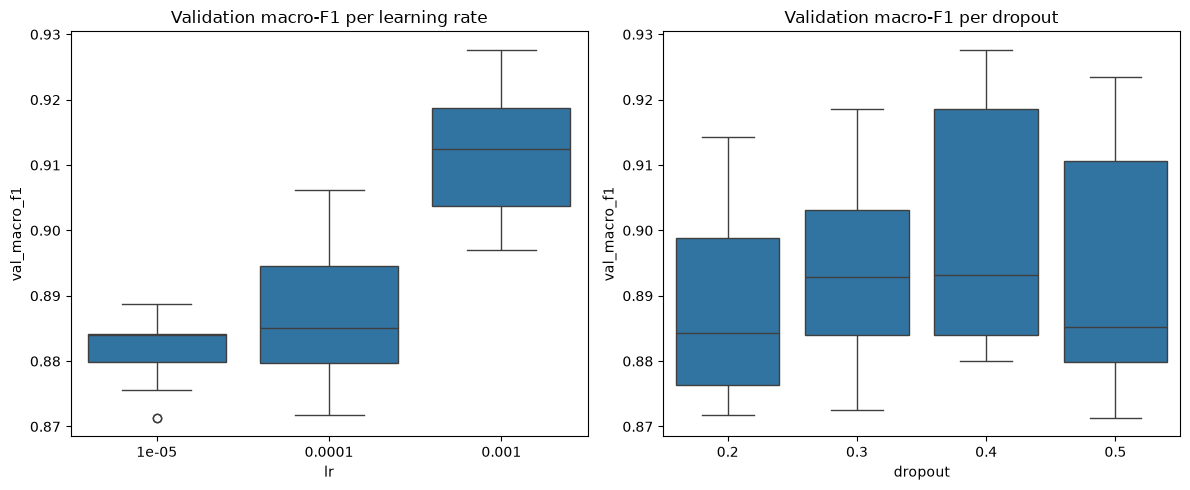

In [20]:
import itertools

GRID_LIMIT = None
GRID_RESULTS_PATH = EVAL_METRICS_DIR / "grid_results.csv"
GRID_KEYS = ("optimizer", "lr", "dropout", "batch_size")


def _grid_key(config) :
    return tuple(str(config[key]) for key in GRID_KEYS)


def _read_completed_grid_keys() :
    if not GRID_RESULTS_PATH.exists() :
        return set()
    completed = pd.read_csv(GRID_RESULTS_PATH)
    return {
        _grid_key({key: row[key] for key in GRID_KEYS})
        for _, row in completed.iterrows()
    }


def _append_grid_result(row) :
    pd.DataFrame([row]).to_csv(
        GRID_RESULTS_PATH,
        mode="a",
        header=not GRID_RESULTS_PATH.exists(),
        index=False,
    )


def _grid_val_summary(history) :
    rows = history["stage1"] + history["stage2"]
    best_row = min(rows, key=lambda row: row["val_loss"])
    return best_row["val_loss"], best_row["val_acc"]


def run_hybrid_grid() :
    configurations = [
        dict(zip(GRID_KEYS, values))
        for values in itertools.product(*(GRID[key] for key in GRID_KEYS))
    ]
    completed_keys = _read_completed_grid_keys()
    pending = [config for config in configurations if _grid_key(config) not in completed_keys]
    if GRID_LIMIT is not None :
        pending = pending[:GRID_LIMIT]
    completed_times = []
    print(f"Grid total={len(configurations)}, selesai={len(completed_keys)}, dijalankan={len(pending)}")

    for index, config in enumerate(pending, start=1) :
        config_start = time.perf_counter()
        status = "ok"
        val_loss = None
        val_acc = None
        val_macro_f1 = None
        epochs_run = 0
        model = None
        try :
            model = build_hybrid(config["dropout"])
            model, history, timing = train_model(
                model,
                config,
                seed=42,
                name=f"Hybrid_grid_{config['optimizer']}_{config['lr']}_{config['dropout']}_{config['batch_size']}",
            )
            val_loss, val_acc = _grid_val_summary(history)
            _, validation_loader = make_loaders(config["batch_size"], 42)
            y_true, y_pred, probs = predict_all(model, validation_loader)
            val_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
            epochs_run = timing["epochs_run"]
        except torch.cuda.OutOfMemoryError as error :
            status = "oom"
            print("OOM:", error)
            if torch.cuda.is_available() :
                torch.cuda.empty_cache()
        finally :
            elapsed = time.perf_counter() - config_start
            completed_times.append(elapsed)
            _append_grid_result({
                "optimizer": config["optimizer"],
                "lr": config["lr"],
                "dropout": config["dropout"],
                "batch_size": config["batch_size"],
                "status": status,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_macro_f1": val_macro_f1,
                "epochs_run": epochs_run,
                "time_sec": elapsed,
            })
            del model
            gc.collect()
            if torch.cuda.is_available() :
                torch.cuda.empty_cache()
        finished = len(completed_times)
        eta = (sum(completed_times) / finished) * (len(pending) - finished)
        print(f"[{finished}/{len(pending)}] {config} status={status} time={elapsed:.1f}s ETA={eta:.1f}s")

    grid_results = pd.read_csv(GRID_RESULTS_PATH)
    grid_results = grid_results.sort_values(
        ["val_macro_f1", "val_loss"], ascending=[False, True], na_position="last",
    ).reset_index(drop=True)
    optimizer_summary = (
        grid_results.groupby(["optimizer", "status"], dropna=False)
        .size()
        .reset_index(name="jumlah")
    )
    print("Ringkasan optimizer:")
    display(optimizer_summary)
    display(grid_results)
    valid_results = grid_results[grid_results["status"] == "ok"].dropna(subset=["val_macro_f1"])
    if valid_results.empty :
        raise RuntimeError("Tidak ada konfigurasi hybrid yang berhasil.")
    best_row = valid_results.iloc[0]
    global BEST_HYBRID_CFG
    BEST_HYBRID_CFG = {
        "optimizer": best_row["optimizer"],
        "lr": float(best_row["lr"]),
        "dropout": float(best_row["dropout"]),
        "batch_size": int(best_row["batch_size"]),
    }
    (EVAL_METRICS_DIR / "best_hybrid_config.json").write_text(
        json.dumps(BEST_HYBRID_CFG, indent=2), encoding="utf-8",
    )
    print("BEST_HYBRID_CFG :", BEST_HYBRID_CFG)

    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=valid_results, x="lr", y="val_macro_f1", ax=axes[0])
    sns.boxplot(data=valid_results, x="dropout", y="val_macro_f1", ax=axes[1])
    axes[0].set_title("Validation macro-F1 per learning rate")
    axes[1].set_title("Validation macro-F1 per dropout")
    figure.tight_layout()
    _save_show_figure(figure, "grid_val_macro_f1.png")
    return grid_results


grid_results = run_hybrid_grid()

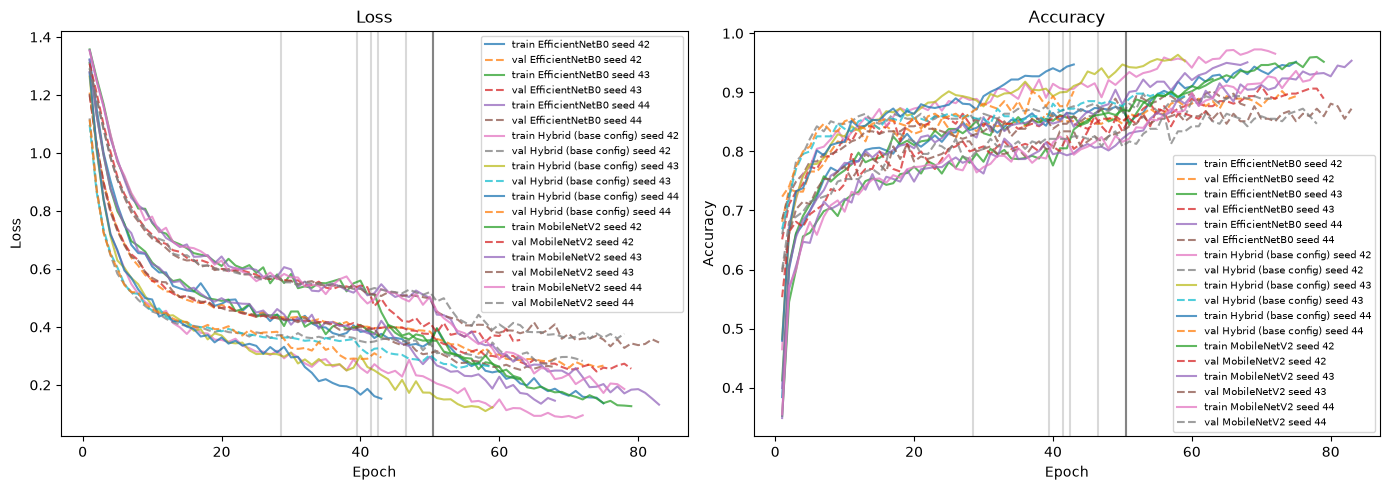

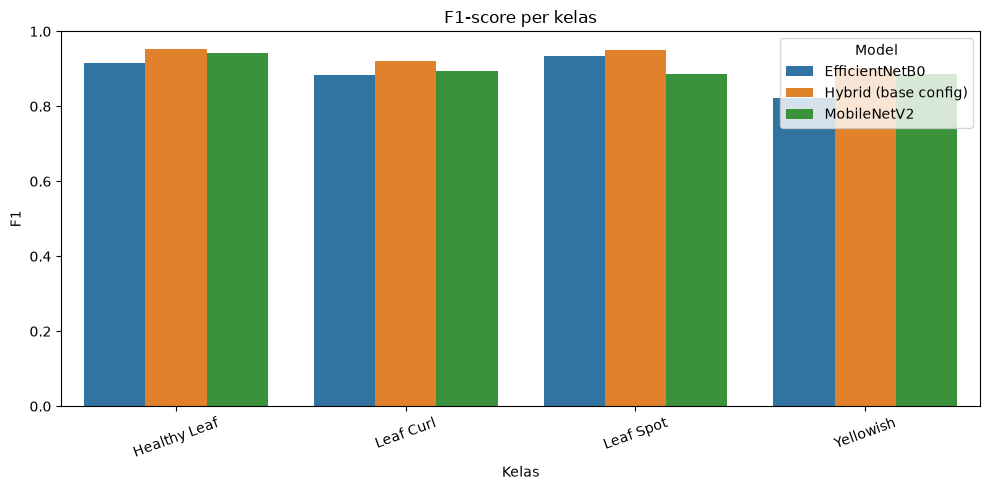

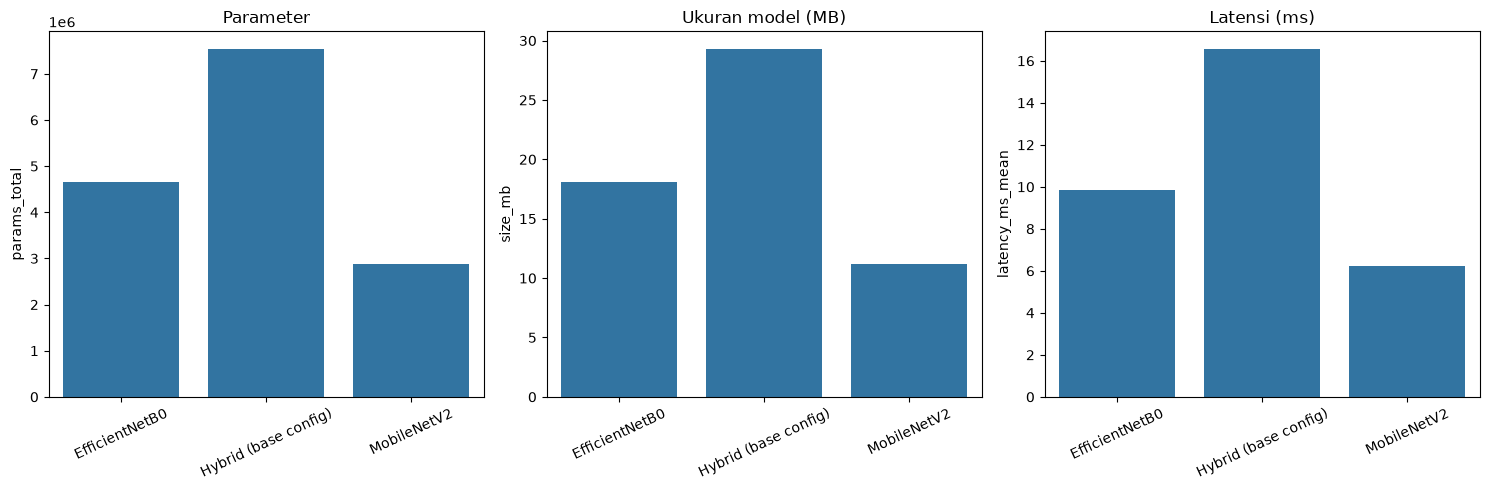

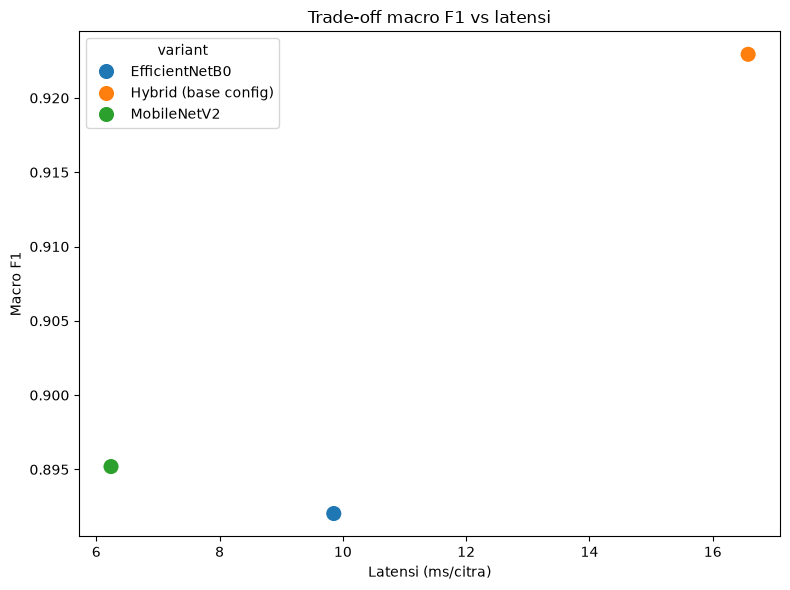

In [21]:
comparison_main.to_csv(EVAL_METRICS_DIR / "comparison_main.csv", index=False)
per_class.to_csv(EVAL_METRICS_DIR / "per_class.csv", index=False)
runs_frame[["variant", "params_total", "size_mb", "latency_ms_mean", "latency_ms_std"]].to_csv(
    EVAL_METRICS_DIR / "efficiency.csv", index=False,
)
plot_training_curves()
plot_confusion_matrices()
plot_f1_per_class()
plot_efficiency()
plot_tradeoff()

# 13. RUN FINAL

stage=1 epoch=1/50 train_loss=1.3401 val_loss=1.2888 train_acc=0.3840 val_acc=0.5745 sec=5.87
stage=1 epoch=2/50 train_loss=1.2441 val_loss=1.1875 train_acc=0.5487 val_acc=0.6979 sec=5.42
stage=1 epoch=3/50 train_loss=1.1521 val_loss=1.0783 train_acc=0.6087 val_acc=0.7021 sec=5.50
stage=1 epoch=4/50 train_loss=1.0467 val_loss=0.9899 train_acc=0.6561 val_acc=0.6894 sec=5.44
stage=1 epoch=5/50 train_loss=0.9547 val_loss=0.9062 train_acc=0.6752 val_acc=0.7234 sec=5.28
stage=1 epoch=6/50 train_loss=0.9200 val_loss=0.8470 train_acc=0.6770 val_acc=0.7064 sec=5.30
stage=1 epoch=7/50 train_loss=0.8497 val_loss=0.8041 train_acc=0.6906 val_acc=0.7191 sec=5.66
stage=1 epoch=8/50 train_loss=0.8115 val_loss=0.7661 train_acc=0.7061 val_acc=0.7362 sec=5.42
stage=1 epoch=9/50 train_loss=0.8024 val_loss=0.7322 train_acc=0.7052 val_acc=0.7617 sec=5.42
stage=1 epoch=10/50 train_loss=0.7750 val_loss=0.7127 train_acc=0.7106 val_acc=0.7532 sec=5.37
stage=1 epoch=11/50 train_loss=0.7277 val_loss=0.6869 train

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280


stage=2 epoch=1/50 train_loss=0.4739 val_loss=0.4679 train_acc=0.8271 val_acc=0.8340 sec=5.58
stage=2 epoch=2/50 train_loss=0.4444 val_loss=0.4971 train_acc=0.8326 val_acc=0.8128 sec=5.45
stage=2 epoch=3/50 train_loss=0.4044 val_loss=0.4432 train_acc=0.8571 val_acc=0.8426 sec=5.51
stage=2 epoch=4/50 train_loss=0.3982 val_loss=0.4238 train_acc=0.8417 val_acc=0.8468 sec=5.52
stage=2 epoch=5/50 train_loss=0.3656 val_loss=0.4125 train_acc=0.8581 val_acc=0.8681 sec=5.55
stage=2 epoch=6/50 train_loss=0.3600 val_loss=0.4328 train_acc=0.8681 val_acc=0.8468 sec=5.40
stage=2 epoch=7/50 train_loss=0.3408 val_loss=0.4107 train_acc=0.8726 val_acc=0.8681 sec=5.51
stage=2 epoch=8/50 train_loss=0.3559 val_loss=0.3799 train_acc=0.8672 val_acc=0.8766 sec=5.65
stage=2 epoch=9/50 train_loss=0.3312 val_loss=0.4075 train_acc=0.8790 val_acc=0.8596 sec=5.66
stage=2 epoch=10/50 train_loss=0.3203 val_loss=0.3969 train_acc=0.8881 val_acc=0.8681 sec=5.72
stage=2 epoch=11/50 train_loss=0.2848 val_loss=0.4115 train

,Backbone,Feature index,Output channels
0,efficientnet,6,192
1,efficientnet,7,320
2,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.4024 val_loss=0.3683 train_acc=0.8389 val_acc=0.8596 sec=5.51
stage=2 epoch=2/50 train_loss=0.3467 val_loss=0.3586 train_acc=0.8662 val_acc=0.8553 sec=5.43
stage=2 epoch=3/50 train_loss=0.3296 val_loss=0.3435 train_acc=0.8735 val_acc=0.8638 sec=5.46
stage=2 epoch=4/50 train_loss=0.3040 val_loss=0.3434 train_acc=0.8844 val_acc=0.8638 sec=5.47
stage=2 epoch=5/50 train_loss=0.2883 val_loss=0.3341 train_acc=0.8944 val_acc=0.8681 sec=5.57
stage=2 epoch=6/50 train_loss=0.2741 val_loss=0.3195 train_acc=0.8954 val_acc=0.8723 sec=5.47
stage=2 epoch=7/50 train_loss=0.2719 val_loss=0.3103 train_acc=0.8954 val_acc=0.8809 sec=5.44
stage=2 epoch=8/50 train_loss=0.2527 val_loss=0.3302 train_acc=0.9190 val_acc=0.8723 sec=5.49
stage=2 epoch=9/50 train_loss=0.2474 val_loss=0.3050 train_acc=0.9108 val_acc=0.8851 sec=5.49
stage=2 epoch=10/50 train_loss=0.2522 val_loss=0.3140 train_acc=0.9026 val_acc=0.8809 sec=5.52
stage=2 epoch=11/50 train_loss=0.2223 val_loss=0.2984 train

...

stage=2 epoch=1/50 train_loss=0.3065 val_loss=0.3321 train_acc=0.8854 val_acc=0.8809 sec=6.17
stage=2 epoch=2/50 train_loss=0.1958 val_loss=0.2751 train_acc=0.9245 val_acc=0.9064 sec=6.73
stage=2 epoch=3/50 train_loss=0.2175 val_loss=0.2977 train_acc=0.9154 val_acc=0.8851 sec=7.60
stage=2 epoch=4/50 train_loss=0.1370 val_loss=0.3274 train_acc=0.9500 val_acc=0.8851 sec=7.59
stage=2 epoch=5/50 train_loss=0.1291 val_loss=0.3333 train_acc=0.9627 val_acc=0.8638 sec=7.47
stage=2 epoch=6/50 train_loss=0.1244 val_loss=0.4081 train_acc=0.9591 val_acc=0.8468 sec=7.50
stage=2 epoch=7/50 train_loss=0.1241 val_loss=0.2808 train_acc=0.9554 val_acc=0.8851 sec=7.49
Early stopping: stage 2, epoch 7.
Final selesai : Hybrid (best grid) seed 44
stage=1 epoch=1/50 train_loss=1.2956 val_loss=1.1297 train_acc=0.4322 val_acc=0.7021 sec=7.60
stage=1 epoch=2/50 train_loss=1.0307 val_loss=0.8863 train_acc=0.6570 val_acc=0.7447 sec=7.55
stage=1 epoch=3/50 train_loss=0.8446 val_loss=0.7365 train_acc=0.7261 val_acc

,Backbone,Feature index,Output channels
0,mobilenet,14,160
1,mobilenet,15,160
2,mobilenet,16,160
3,mobilenet,17,320
4,mobilenet,18,1280
5,efficientnet,6,192
6,efficientnet,7,320
7,efficientnet,8,1280


stage=2 epoch=1/50 train_loss=0.3174 val_loss=0.3603 train_acc=0.8817 val_acc=0.8681 sec=8.60
stage=2 epoch=2/50 train_loss=0.2981 val_loss=0.3297 train_acc=0.8844 val_acc=0.8809 sec=8.61
stage=2 epoch=3/50 train_loss=0.2981 val_loss=0.3307 train_acc=0.8944 val_acc=0.8723 sec=8.62
stage=2 epoch=4/50 train_loss=0.2688 val_loss=0.3369 train_acc=0.9035 val_acc=0.8553 sec=8.72
stage=2 epoch=5/50 train_loss=0.2435 val_loss=0.3235 train_acc=0.9108 val_acc=0.8723 sec=8.97
stage=2 epoch=6/50 train_loss=0.2238 val_loss=0.3486 train_acc=0.9163 val_acc=0.8723 sec=8.21
stage=2 epoch=7/50 train_loss=0.2191 val_loss=0.3284 train_acc=0.9263 val_acc=0.8723 sec=8.81
stage=2 epoch=8/50 train_loss=0.2279 val_loss=0.3137 train_acc=0.9190 val_acc=0.8809 sec=8.33
stage=2 epoch=9/50 train_loss=0.1877 val_loss=0.3019 train_acc=0.9318 val_acc=0.8851 sec=8.83
stage=2 epoch=10/50 train_loss=0.2036 val_loss=0.2919 train_acc=0.9336 val_acc=0.8894 sec=8.61
stage=2 epoch=11/50 train_loss=0.1850 val_loss=0.3035 train

,Model,Accuracy terbaik,Precision macro terbaik,Recall macro terbaik,F1 macro terbaik,Params,Ukuran MB terkecil,Inferensi ms/citra tercepat
0,EfficientNetB0,0.9110,0.9113,0.9101,0.9097,4665472,18.0840,10.2768
1,Hybrid (base config),0.9322,0.9325,0.9322,0.9314,7544704,29.3145,16.8884
2,Hybrid (best grid),0.9280,0.9282,0.9266,0.9265,7544704,29.3145,17.0973
3,MobileNetV2,0.9025,0.9035,0.9025,0.9026,2881796,11.2284,6.1807


,Model,n primer,Acc primer terbaik,F1 primer terbaik,n sekunder,Acc sekunder terbaik,F1 sekunder terbaik
0,EfficientNetB0,74,0.9054,0.9051,162,0.9136,0.9111
1,Hybrid (base config),74,0.9459,0.9459,162,0.9444,0.9436
2,Hybrid (best grid),74,0.9595,0.9591,162,0.9136,0.9105
3,MobileNetV2,74,0.8649,0.8671,162,0.9321,0.9317


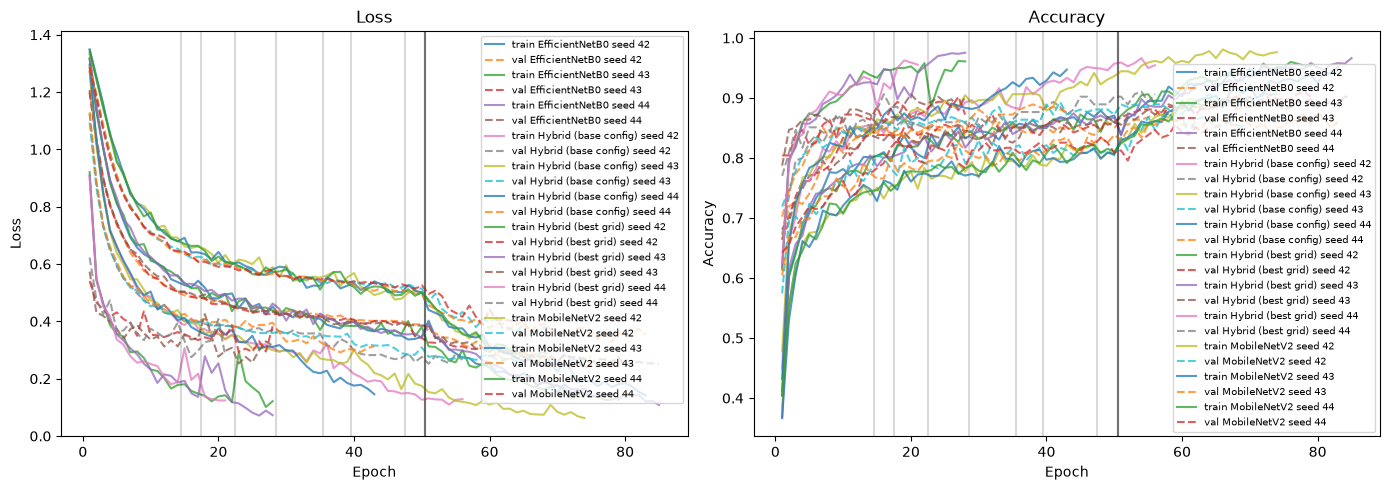

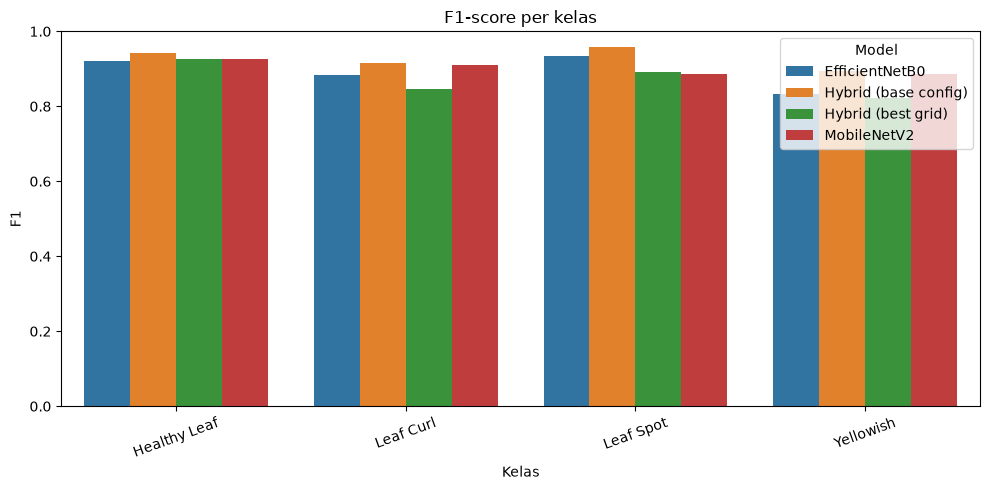

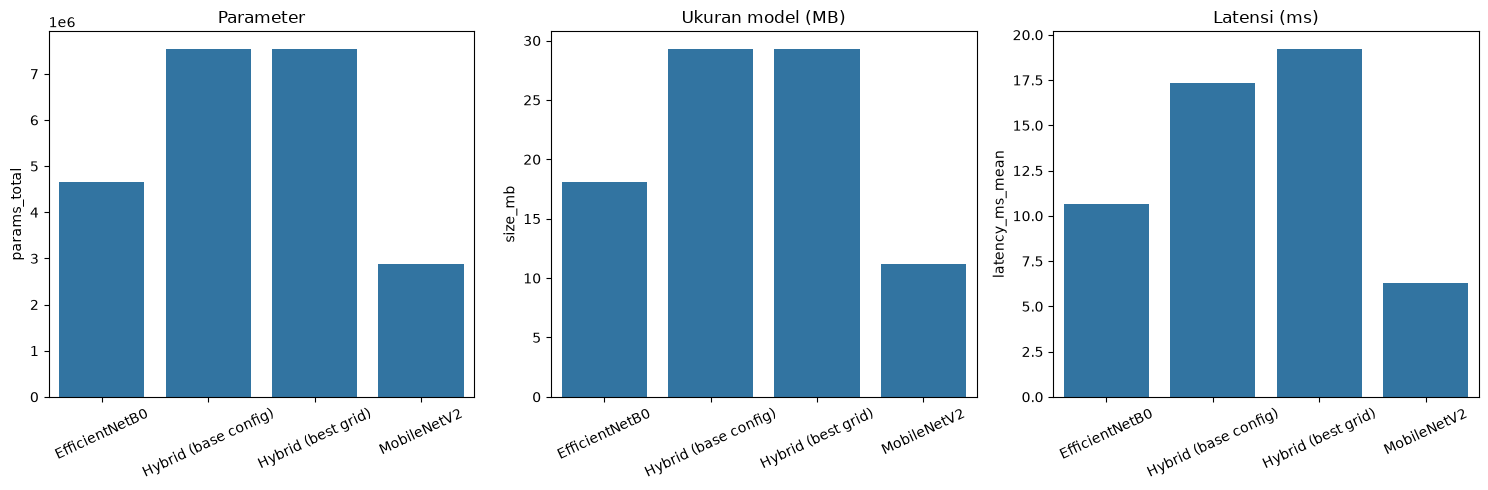

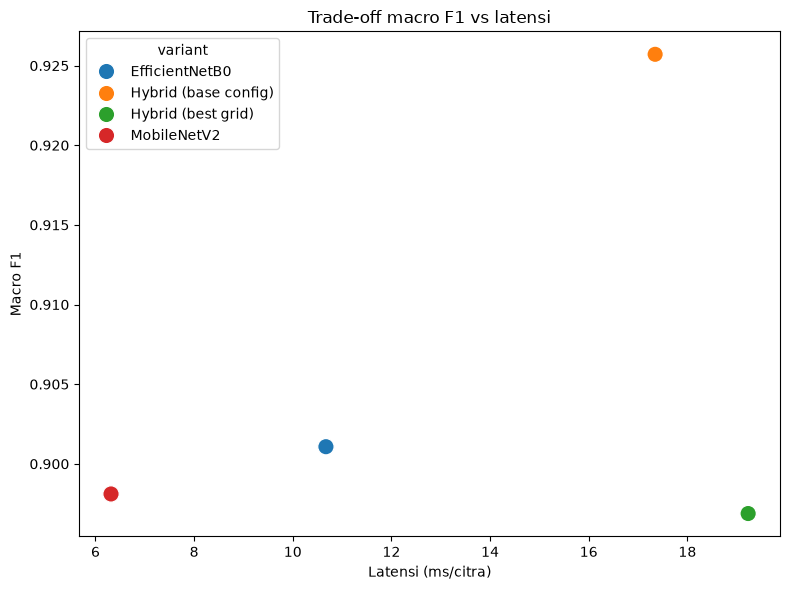

Final reports diperbarui di reports


In [22]:
final_configs = [
    ("MobileNetV2", build_mobilenet, BASE_CONFIG),
    ("EfficientNetB0", build_efficientnet, BASE_CONFIG),
    ("Hybrid (best grid)", build_hybrid, BEST_HYBRID_CFG),
    ("Hybrid (base config)", build_hybrid, BASE_CONFIG),
]
final_runs = []
for run_seed in SEEDS :
    for variant_name, builder, config in final_configs :
        run_row, run_payload = run_experiment(variant_name, builder, config, run_seed)
        final_runs.append(run_row)
        print("Final selesai :", variant_name, "seed", run_seed)

runs_frame, comparison_main, per_class, per_source = build_comparison_tables()
print("\nPerbandingan final")
display(comparison_main)
display(per_source)
comparison_main.to_csv(EVAL_METRICS_DIR / "comparison_main.csv", index=False)
per_class.to_csv(EVAL_METRICS_DIR / "per_class.csv", index=False)
runs_frame[["variant", "params_total", "size_mb", "latency_ms_mean", "latency_ms_std"]].to_csv(
    EVAL_METRICS_DIR / "efficiency.csv", index=False,
)
plot_training_curves()
plot_confusion_matrices()
plot_f1_per_class()
plot_efficiency()
plot_tradeoff()
print("Final reports diperbarui di", EVAL_REPORT_DIR)